#### Visuals for 2021-23 Data

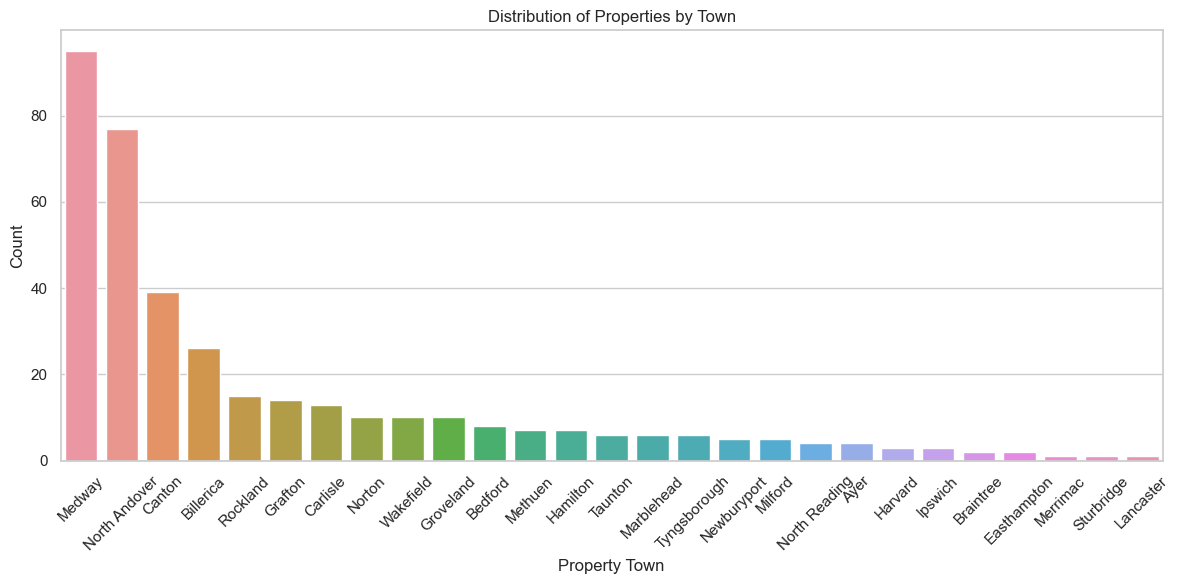

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the data
df = pd.read_csv('madison_merged_resale_chapa_21_23.csv')

# visual style 
sns.set(style = "whitegrid")

# distribution of property towns
plt.figure(figsize = (12,6))
town_order = df['Property Town'].value_counts().index
sns.countplot(data = df, x = 'Property Town', order = town_order)
plt.title("Distribution of Properties by Town")
plt.xticks(rotation = 45)
plt.xlabel("Property Town")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

This shows the distribution of properties available to apply to by the town for the 2021-2023 data. It is clear that Medway has the most amount of properties, followed by North Andover.

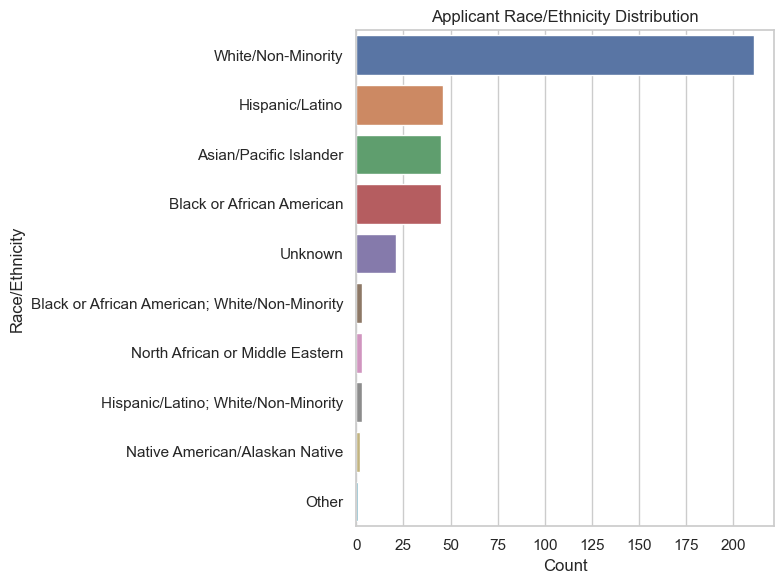

In [2]:
# distribution of applicant race/ethnicity
plt.figure(figsize = (8,6))
race_order = df['CHAPA Race/Ethnicity'].value_counts().index
sns.countplot(data = df, y = 'CHAPA Race/Ethnicity', order = race_order)
plt.title("Applicant Race/Ethnicity Distribution")
plt.xlabel("Count")
plt.ylabel("Race/Ethnicity")
plt.tight_layout()
plt.show()

The applicant race/ethnicity count is shown in this chart. A majority of the applicants are White/Non-Minority. 

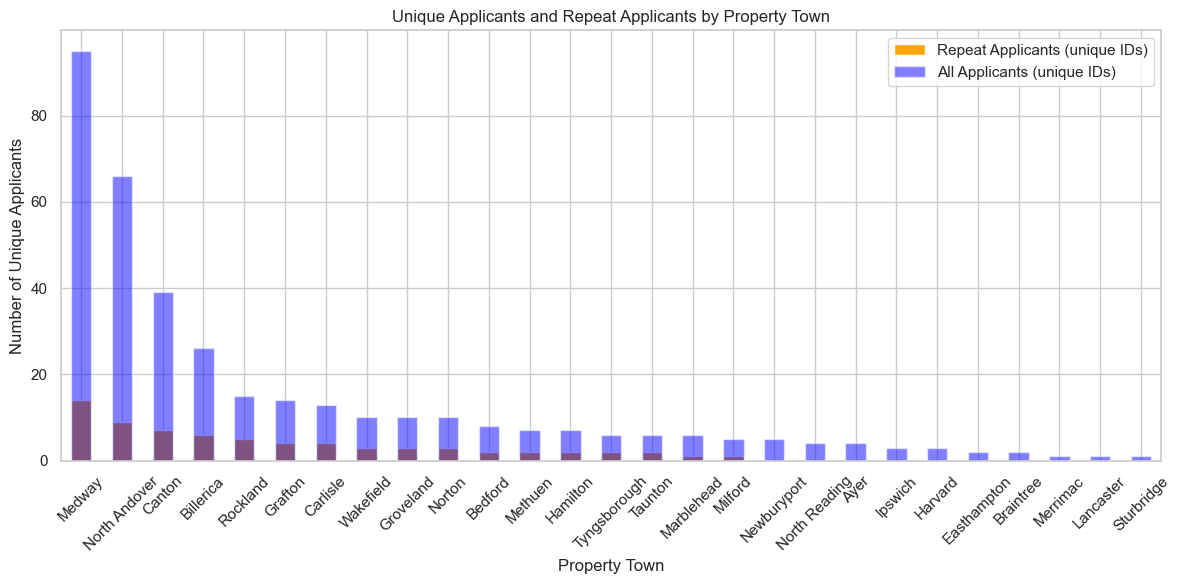

In [3]:
# count number of applications per ID 
app_counts = df['ID Number'].value_counts()
df['repeat_applicant'] = df['ID Number'].map(app_counts) > 1

# unique repeat applicant counts by property town
repeat_town_counts = df[df['repeat_applicant']].groupby('Property Town')['ID Number'].nunique().sort_values(ascending = False)
all_town_counts = df.groupby('Property Town')['ID Number'].nunique().sort_values(ascending = False)

plt.figure(figsize = (12,6))
repeat_town_counts.plot(kind = 'bar', color = 'orange', label = 'Repeat Applicants (unique IDs)')
all_town_counts.plot(kind = 'bar', color = 'blue', alpha = 0.5, label = 'All Applicants (unique IDs)')
plt.title("Unique Applicants and Repeat Applicants by Property Town")
plt.ylabel("Number of Unique Applicants")
plt.xlabel("Property Town")
plt.xticks(rotation = 45)
plt.legend()
plt.tight_layout()
plt.show()

This chart analyzes repeat vs. all applicants. There is a clear trend between property pool and number of applications received for that property; some towns/cities receive significantly more Repeat Applicants

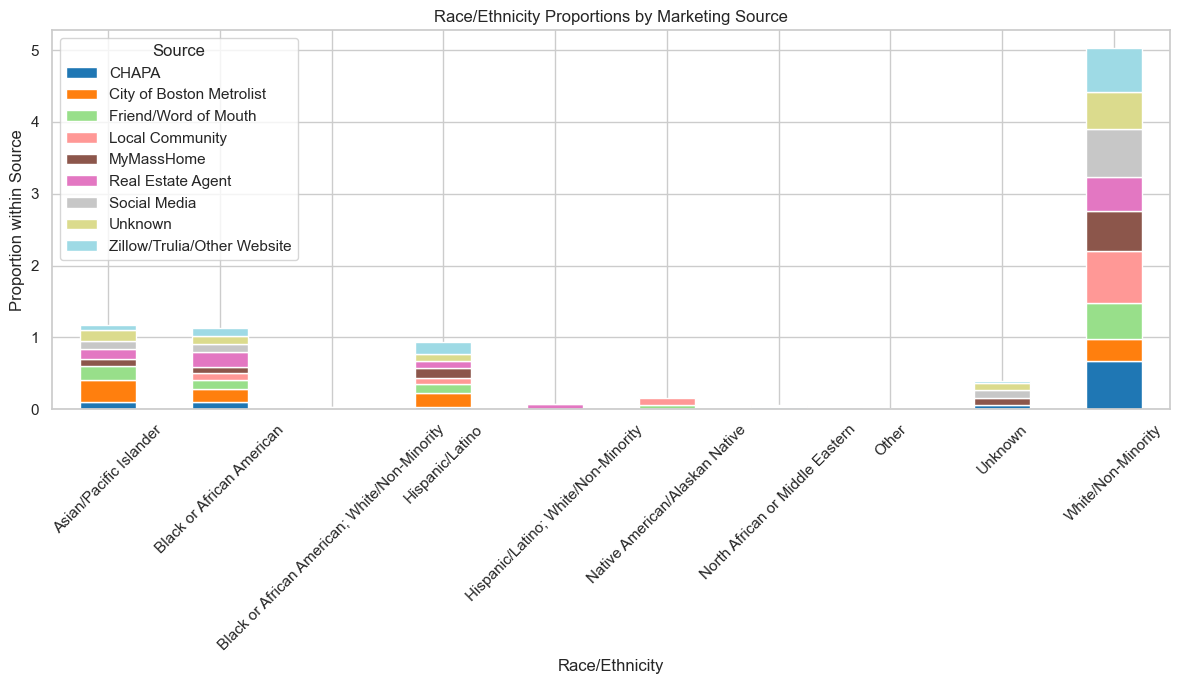

In [4]:
# race counts by Source
race_source_counts = df.groupby(['Source', 'CHAPA Race/Ethnicity']).size().unstack(fill_value = 0)

# normalize per source to get proportions
race_source_props = race_source_counts.div(race_source_counts.sum(axis = 1), axis = 0)

# plot race proportions per Source
race_source_props.T.plot(kind = 'bar', stacked = True, figsize = (12,7), colormap = 'tab20')
plt.title("Race/Ethnicity Proportions by Marketing Source")
plt.ylabel("Proportion within Source")
plt.xlabel("Race/Ethnicity")
plt.xticks(rotation = 45)
plt.legend(title = 'Source')
plt.tight_layout()
plt.show()

Race/ethnicity proportions by marketing source are shown here. This tells us which marketing source reached which race demographic of applicants. Zillow/Trulia/Other Website seems to be the largest marketing source for White/Non-Minority and City of Boston Metrolist for Pacific Islander, Black or African American, and Hispanic/Latino. 